1) Importamos librerías

In [1]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 
import pandas as pd

from utils import *

from matplotlib import gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

import wfdb
from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import RepeatedStratifiedKFold

from tqdm import tqdm
from persim import PersistenceImager, PersLandscapeApprox

In [ ]:
# wfdb.dl_database("mitdb", dl_dir="mitbih_data")

2) Definimos funciones

In [5]:

def load_mitbih_beats(record_id="100", window=200):

    record = wfdb.rdrecord(f"mitbih_data/{record_id}")
    annotation = wfdb.rdann(f"mitbih_data/{record_id}", "atr")

    signal = record.p_signal[:, 0]  # MLII

    X = []
    y = []

    for i, label in enumerate(annotation.symbol):

        if label not in ["N", "V"]:  # binario simple para empezar
            continue

        idx = annotation.sample[i]

        if idx - window < 0 or idx + window > len(signal):
            continue

        beat = signal[idx - window: idx + window]

        X.append(beat)
        y.append(0 if label == "N" else 1)

    return np.array(X), np.array(y)


def load_mitbih_all(records_id, window=200, classes=("N", "V")):
    """
    Loads all MIT-BIH records into a single dataset.

    Returns:
        X: (n_beats, 2*window)
        y: (n_beats,)
    """

    X_all = []
    y_all = []

    for rec in tqdm(records_id):

        try:
            record = wfdb.rdrecord(f"mitbih_data/{rec}")
            ann = wfdb.rdann(f"mitbih_data/{rec}", "atr")

            signal = record.p_signal[:, 0]  # MLII

            for i, label in enumerate(ann.symbol):

                if label not in classes:
                    continue

                idx = ann.sample[i]

                if idx - window < 0 or idx + window >= len(signal):
                    continue

                beat = signal[idx - window: idx + window]

                X_all.append(beat)
                y_all.append(0 if label == classes[0] else 1)

        except Exception as e:
            print(f"Skipping record {rec}: {e}")

    return np.array(X_all), np.array(y_all)



def signal_to_curve(signal):
    """
    Converts 1D time series into 2D curve safely.
    """
    signal = np.array(signal).astype(float).squeeze()  # 🔴 clave

    t = np.arange(len(signal)).astype(float)

    # normalize
    x = (t - np.min(t)) / (np.max(t) - np.min(t) + 1e-8)
    y = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)

    return x, y


def build_dataset_from_ecg(X_raw, y_raw, layer, n_points=400):
    """
    Builds PET dataset from TwoLeadECG.
    """

    X_pet = []
    y_labels = []

    for signal, label in tqdm(zip(X_raw, y_raw)):

        # convert signal to geometric curve
        x, y = signal_to_curve(signal)

        # resample to fixed number of points (important for PET stability)
        idx = np.linspace(0, len(x) - 1, n_points).astype(int)
        x = x[idx]
        y = y[idx]

        pet, _ = compute_pet_from_shape(x, y, layer)

        X_pet.append(pet)
        y_labels.append(int(label))

    return np.array(X_pet), np.array(y_labels)

def build_dataset_pe_from_ecg(X_raw, y_raw, layer, n_points):
    """
    Builds Persistent Entropy (single feature) dataset.
    """

    X_pe = []
    y_labels = []

    for signal, label in tqdm(zip(X_raw, y_raw)):

        x, y = signal_to_curve(signal)

        idx = np.linspace(0, len(x)-1, n_points).astype(int)
        x = x[idx]
        y = y[idx]

        pe = compute_global_pe(x, layer)

        X_pe.append([pe])      # shape = (1,)
        y_labels.append(int(label))

    return np.array(X_pe), np.array(y_labels)

def balance_dataset(X, y):

    idx_n = np.where(y == 0)[0]
    idx_v = np.where(y == 1)[0]

    idx_n = np.random.choice(idx_n, size=len(idx_v), replace=False)

    idx = np.concatenate([idx_n, idx_v])

    return X[idx], y[idx]

def compute_global_pe(y, layer):
    """
    Global persistent entropy (single filtration).
    """
    y_tf = tf.constant(y, dtype=tf.float32)

    dgms = layer.call(y_tf)
    dgm = dgms[0][0]

    return persistent_entropy(dgm)

def compute_persistence_diagram(y, layer):

    y_tf = tf.constant(y, dtype=tf.float32)

    dgms = layer.call(y_tf)

    dgm = dgms[0][0].numpy()

    dgm = dgm[np.isfinite(dgm[:,1])]

    return dgm

pimgr = PersistenceImager(
    pixel_size=0.05
)

def persistence_image_features(dgm):

    img = pimgr.transform(dgm)

    return img.flatten()

def build_dataset_pi(X_raw, y_raw, layer, n_points):

    X_pi = []
    y_labels = []

    for signal, label in zip(X_raw, y_raw):

        x, y = signal_to_curve(signal)

        idx = np.linspace(
            0,
            len(x)-1,
            n_points
        ).astype(int)

        y = y[idx]

        dgm = compute_persistence_diagram(
            y,
            layer
        )

        feat = persistence_image_features(dgm)

        X_pi.append(feat)
        y_labels.append(int(label))

    return np.array(X_pi), np.array(y_labels)

def persistence_landscape_features(
        dgm,
        n_bins=100,
        k_max=5):

    if len(dgm) == 0:
        return np.zeros(k_max*n_bins)

    births = dgm[:,0]
    deaths = dgm[:,1]

    grid = np.linspace(
        births.min(),
        deaths.max(),
        n_bins
    )

    landscapes = []

    for t in grid:

        vals = []

        for b,d in zip(births,deaths):

            val = max(
                0,
                min(t-b,d-t)
            )

            vals.append(val)

        vals = sorted(vals, reverse=True)

        for k in range(k_max):

            if k < len(vals):
                landscapes.append(vals[k])
            else:
                landscapes.append(0)

    return np.array(landscapes)

def betti_curve_features(
        dgm,
        n_bins=100):

    births = dgm[:,0]
    deaths = dgm[:,1]

    tmin = births.min()
    tmax = deaths.max()

    grid = np.linspace(
        tmin,
        tmax,
        n_bins
    )

    curve = []

    for t in grid:

        betti = np.sum(
            (births <= t) &
            (deaths > t)
        )

        curve.append(betti)

    return np.array(curve)

def build_dataset_descriptor(
        X_raw,
        y_raw,
        layer,
        n_points,
        descriptor):

    X_out = []
    y_out = []

    for signal, label in zip(X_raw, y_raw):

        x, y = signal_to_curve(signal)

        idx = np.linspace(
            0,
            len(x)-1,
            n_points
        ).astype(int)

        y = y[idx]

        feat = descriptor(y, layer)

        X_out.append(feat)

        y_out.append(int(label))

    return np.array(X_out), np.array(y_out)

def descriptor_pe(y, layer):

    dgm = compute_persistence_diagram(
        y,
        layer
    )

    if len(dgm) == 0:
        return np.array([0.0])

    pe = persistent_entropy(dgm)

    return np.array([pe])


def descriptor_pi(y, layer):

    dgm = compute_persistence_diagram(
        y,
        layer
    )

    return persistence_image_features(dgm)


def descriptor_bc(y, layer):

    dgm = compute_persistence_diagram(
        y,
        layer
    )

    return betti_curve_features(dgm)


def descriptor_pl(y, layer):

    dgm = compute_persistence_diagram(
        y,
        layer
    )

    return persistence_landscape_features(dgm)

def descriptor_pet(signal, layer):

    x, y = signal_to_curve(signal)

    pet, _ = compute_pet_from_shape(
        x,
        y,
        layer
    )

    return pet

def build_dataset_pet(
        X_raw,
        y_raw,
        layer,
        n_points):

    X_pet = []
    y_pet = []

    for signal, label in zip(X_raw, y_raw):

        x, y = signal_to_curve(signal)

        idx = np.linspace(
            0,
            len(x)-1,
            n_points
        ).astype(int)

        x = x[idx]
        y = y[idx]

        pet,_ = compute_pet_from_shape(
            x,
            y,
            layer
        )

        X_pet.append(pet)

        y_pet.append(int(label))

    return np.array(X_pet), np.array(y_pet)

def experiment_ecg(
    X,
    y,
    layer,
    n_points,
    n_splits=5,
    n_repeats=10,
    random_state=42,
):

    print("\n============================================")
    print("ECG Classification Experiment")
    print("Repeated Stratified Cross Validation")
    print("============================================")

    # -----------------------------------------------------
    # Labels -> 0,1
    # -----------------------------------------------------
    classes = np.unique(y)

    mapping = {
        c: i
        for i, c in enumerate(classes)
    }

    y = np.array([
        mapping[c]
        for c in y
    ])

    # -----------------------------------------------------
    # RAW
    # -----------------------------------------------------
    X_raw = np.squeeze(X)

    # -----------------------------------------------------
    # PE
    # -----------------------------------------------------
    print("\n--- BUILDING PE DATASET")

    X_pe, _ = build_dataset_descriptor(
        X,
        y,
        layer,
        n_points,
        descriptor_pe
    )

    print("DONE")

    # -----------------------------------------------------
    # BETTI CURVES
    # -----------------------------------------------------
    print("\n--- BUILDING BETTI CURVE DATASET")

    X_bc, _ = build_dataset_descriptor(
        X,
        y,
        layer,
        n_points,
        descriptor_bc
    )

    print("DONE")

    # -----------------------------------------------------
    # PERSISTENCE LANDSCAPES
    # -----------------------------------------------------
    print("\n--- BUILDING PERSISTENCE LANDSCAPE DATASET")

    X_pl, _ = build_dataset_descriptor(
        X,
        y,
        layer,
        n_points,
        descriptor_pl
    )

    print("DONE")

    # -----------------------------------------------------
    # PERSISTENCE IMAGES
    # -----------------------------------------------------
    print("\n--- BUILDING PERSISTENCE IMAGE DATASET")

    X_pi, _ = build_dataset_descriptor(
        X,
        y,
        layer,
        n_points,
        descriptor_pi
    )

    print("DONE")

    # -----------------------------------------------------
    # PET
    # -----------------------------------------------------
    print("\n--- BUILDING PET DATASET")

    X_pet, _ = build_dataset_pet(
        X,
        y,
        layer,
        n_points
    )

    print("DONE")

    # -----------------------------------------------------
    # REPRESENTATIONS
    # -----------------------------------------------------
    datasets = {

        "Raw":
            X_raw,

        "PE":
            X_pe,

        "Betti Curve":
            X_bc,

        "Persistence Landscape":
            X_pl,

        "Persistence Image":
            X_pi,

        "PET":
            X_pet
    }

    # -----------------------------------------------------
    # MODELS
    # -----------------------------------------------------
    models = {

        "SVM":
            SVC(
                kernel="linear",
                C=1,
                probability=True,
                random_state=random_state
            ),

        "Random Forest":
            RandomForestClassifier(
                n_estimators=300,
                random_state=random_state
            ),

        "XGBoost":
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=random_state
            )
    }

    # -----------------------------------------------------
    # CROSS VALIDATION
    # -----------------------------------------------------
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )

    results = []

    # -----------------------------------------------------
    # LOOP
    # -----------------------------------------------------
    for representation, X_repr in datasets.items():

        print("\n" + "=" * 70)
        print(representation)
        print("Dimension:", X_repr.shape[1])
        print("=" * 70)

        for model_name, model in models.items():

            acc_scores = []
            bal_scores = []
            f1_scores = []
            auc_scores = []

            for train_idx, test_idx in cv.split(X_repr, y):

                X_train = X_repr[train_idx]
                X_test = X_repr[test_idx]

                y_train = y[train_idx]
                y_test = y[test_idx]

                clf = clone(model)

                clf.fit(
                    X_train,
                    y_train
                )

                pred = clf.predict(X_test)

                if hasattr(clf, "predict_proba"):

                    prob = clf.predict_proba(
                        X_test
                    )[:, 1]

                else:

                    prob = clf.decision_function(
                        X_test
                    )

                acc_scores.append(
                    accuracy_score(
                        y_test,
                        pred
                    )
                )

                bal_scores.append(
                    balanced_accuracy_score(
                        y_test,
                        pred
                    )
                )

                f1_scores.append(
                    f1_score(
                        y_test,
                        pred
                    )
                )

                auc_scores.append(
                    roc_auc_score(
                        y_test,
                        prob
                    )
                )

            acc_mean = np.mean(acc_scores)
            acc_std = np.std(acc_scores)

            bal_mean = np.mean(bal_scores)
            bal_std = np.std(bal_scores)

            f1_mean = np.mean(f1_scores)
            f1_std = np.std(f1_scores)

            auc_mean = np.mean(auc_scores)
            auc_std = np.std(auc_scores)

            print(
                f"{model_name:15s}"
                f" ACC={acc_mean:.4f}±{acc_std:.4f}"
                f" BAL={bal_mean:.4f}±{bal_std:.4f}"
                f" F1={f1_mean:.4f}±{f1_std:.4f}"
                f" AUC={auc_mean:.4f}±{auc_std:.4f}"
            )

            results.append({

                "Representation":
                    representation,

                "Dimension":
                    X_repr.shape[1],

                "Model":
                    model_name,

                "Accuracy Mean":
                    acc_mean,

                "Accuracy Std":
                    acc_std,

                "Balanced Accuracy Mean":
                    bal_mean,

                "Balanced Accuracy Std":
                    bal_std,

                "F1 Mean":
                    f1_mean,

                "F1 Std":
                    f1_std,

                "ROC-AUC Mean":
                    auc_mean,

                "ROC-AUC Std":
                    auc_std,
            })

    # -----------------------------------------------------
    # DATAFRAME
    # -----------------------------------------------------
    results = pd.DataFrame(results)

    print("\n============================================")
    print("SUMMARY")
    print("============================================")

    print(results)

    # -----------------------------------------------------
    # SAVE CSV
    # -----------------------------------------------------
    results.to_csv(
        "mitbih_results.csv",
        index=False
    )

    return results

def plot_two_signals(X, y):
    """
    Plots one example per class from TwoLeadECG.
    """

    X = np.array(X)
    y = np.array(y)

    # find one sample per class
    idx_class_0 = np.where(y == 0)[0]
    idx_class_1 = np.where(y == 1)[0]

    sig0 = np.squeeze(X[idx_class_0])
    sig1 = np.squeeze(X[idx_class_1])

    t0 = np.arange(len(sig0))
    t1 = np.arange(len(sig1))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(t0, sig0)
    plt.title("TwoLeadECG - Class (Normal)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.subplot(1, 2, 2)
    plt.plot(t1, sig1)
    plt.title("TwoLeadECG - Class 1 (PVC)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles



3) Vemos el dataset

In [3]:
# una muestra
X, y = load_mitbih_beats(record_id=106)

print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

print(dict(zip(unique, counts)))


# varias muestras
records = [
    "100","101","102","103","104","105","106","107","108","109",
    "111","112","113","114","115","116","117","118","119","121",
    "122","123","124","200","201","202","203","205","207","208",
    "209","210","212","213","214"
]

X, y = load_mitbih_all(records_id=records)

print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

dict(zip(unique, counts))

X, y = balance_dataset(X, y)
print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

dict(zip(unique, counts))

X[0].shape

(2027, 400)
(2027,)
{np.int64(0): np.int64(1507), np.int64(1): np.int64(520)}


100%|██████████| 35/35 [00:02<00:00, 16.98it/s]

(56906, 400)
(56906,)
(9344, 400)
(9344,)


(400,)

1162 señales de longitud 82, con una muestra balanceada: 581 ecg clasificadas en tipo 1 y 581 clasificadas en tipo 2. Tipo 1 es latidos con patron normal, tipo 2 es latido con morfologia istinta.

4) Visualizamos señales de ambos tipos

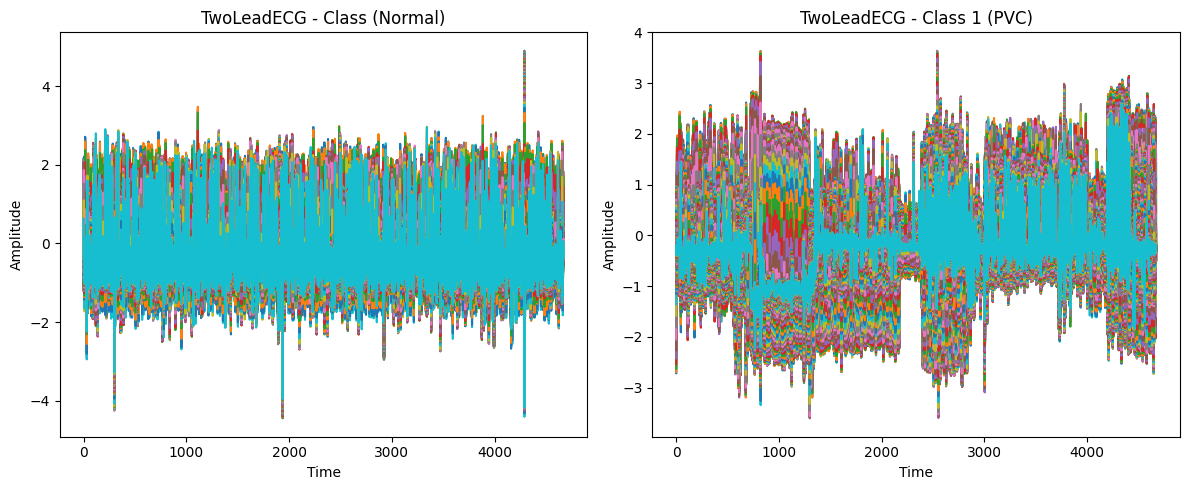

In [13]:
plot_two_signals(X,y)

5) Run SVM using PET as input data

En total

In [ ]:
n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_ecg(X, y, layer, n_points=n_points)


ECG Classification Experiment
Repeated Stratified Cross Validation

--- BUILDING PE DATASET
DONE

--- BUILDING BETTI CURVE DATASET
DONE

--- BUILDING PERSISTENCE LANDSCAPE DATASET
DONE

--- BUILDING PERSISTENCE IMAGE DATASET
DONE

--- BUILDING PET DATASET
DONE

Raw
Dimension: 400
